In [10]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
import torch.nn as nn
import torch
from tqdm.autonotebook import tqdm
import seaborn as sns
import os, sys

from matplotlib.lines import Line2D
from collections import defaultdict
from matplotlib.colors import LinearSegmentedColormap
# Root project
project_root = os.path.abspath(os.path.join(os.getcwd(), "../../.."))

if project_root not in sys.path:
    sys.path.append(project_root)

print("Project root added to sys.path:", project_root)

from envs import *
from basal_ganglia import *
from stn_gpe import *

# filter warnings
import warnings
warnings.filterwarnings("ignore")
import pickle

Project root added to sys.path: /Users/charithapalika/Desktop/Lab projects/Decision Making/light_house_DBS_decision_making


## Hyperparameters


In [11]:
TRAILS = 100
EPOCHS = 10 #100
NUM_BINS = 5
LR = 0.1 #0.00075
NUM_ARMS = 4
SCALING_FACTOR = 100
REW_STD = 0
LOSS_STD = 0
VAR = 0.1

## Simulation

In [12]:
env = IGTEnv(mean_reward=np.array([100,100,50,50])/SCALING_FACTOR,
             std_reward=np.array([REW_STD,REW_STD,REW_STD,REW_STD])/SCALING_FACTOR,
             mean_loss=np.array([-250,-1250,-50,-250])/SCALING_FACTOR,
             std_loss=np.array([LOSS_STD,LOSS_STD,LOSS_STD,LOSS_STD])/SCALING_FACTOR)

In [13]:

# ==================================================
# Choice variability and Q-value error metrics for IGT
# ==================================================

import numpy as np
import torch

# True expected net value per deck on normalized reward scale.
# A: 100 + 0.5*(-250) = -25
# B: 100 + 0.1*(-1250) = -25
# C: 50  + 0.5*(-50)  =  25
# D: 50  + 0.1*(-250) =  25
TRUE_IGT_VALUES = np.array([-25, -25, 25, 25], dtype=float) / SCALING_FACTOR


def _to_numpy(x):
    if hasattr(x, "detach"):
        x = x.detach().cpu().numpy()
    elif hasattr(x, "cpu"):
        x = x.cpu().numpy()
    return np.asarray(x)


def compute_choice_variability_metrics(arm_chosen_monitor, n_arms=4, window_size=15, alpha=0.7):
    """
    Computes choice variability from action choices.
    entropy + switching = alpha * normalized entropy + (1-alpha) * switching rate
    """
    choices = _to_numpy(arm_chosen_monitor).astype(int)

    if choices.ndim == 1:
        choices = choices[None, :]

    epochs, trials = choices.shape
    window_size = min(window_size, trials)

    entropy_by_epoch = []
    switching_by_epoch = []
    combined_by_epoch = []

    for e in range(epochs):
        entropy_windows = []
        switching_windows = []
        combined_windows = []

        for start in range(0, trials - window_size + 1):
            end = start + window_size
            w = choices[e, start:end]

            counts = np.bincount(w, minlength=n_arms).astype(float)
            probs = counts / np.sum(counts)
            probs = probs[probs > 0]

            entropy = -np.sum(probs * np.log(probs)) / np.log(n_arms)
            switching = np.mean(w[1:] != w[:-1]) if len(w) > 1 else 0.0
            combined = alpha * entropy + (1 - alpha) * switching

            entropy_windows.append(entropy)
            switching_windows.append(switching)
            combined_windows.append(combined)

        entropy_by_epoch.append(np.mean(entropy_windows))
        switching_by_epoch.append(np.mean(switching_windows))
        combined_by_epoch.append(np.mean(combined_windows))

    return {
        "window_size": window_size,
        "alpha_entropy": alpha,
        "mean_entropy": float(np.mean(entropy_by_epoch)),
        "mean_switching": float(np.mean(switching_by_epoch)),
        "mean_combined_variability": float(np.mean(combined_by_epoch)),
    }


def dp_monitor_to_array(dp_monitor, n_arms=4):
    """
    Converts dp_monitor from {arm: tensor(epochs, trials, 1)} to array(epochs, trials, arms).
    """
    q_list = []
    for arm in range(n_arms):
        q_arm = _to_numpy(dp_monitor[arm])
        q_arm = np.squeeze(q_arm)
        if q_arm.ndim == 1:
            q_arm = q_arm[None, :]
        q_list.append(q_arm)

    return np.stack(q_list, axis=-1)


def compute_q_error_metrics(dp_monitor, true_values, n_arms=4):
    """
    Computes Q-value error by comparing DP values to true expected deck values.
    true_values should be on the same normalized scale as dp_monitor.
    """
    q_values = dp_monitor_to_array(dp_monitor, n_arms=n_arms)  # epochs x trials x arms
    true_values = np.asarray(true_values, dtype=float).reshape(1, 1, n_arms)

    q_err = q_values - true_values
    q_rmse_by_trial = np.sqrt(np.mean(q_err ** 2, axis=-1))
    q_mae_by_trial = np.mean(np.abs(q_err), axis=-1)

    q_best = np.argmax(q_values, axis=-1)
    true_best_arms = np.where(np.asarray(true_values).reshape(-1) == np.max(true_values))[0]
    q_best_arm_agreement = np.isin(q_best, true_best_arms).astype(float)

    return {
        "true_values": np.asarray(true_values).reshape(-1),
        "mean_q_rmse": float(np.mean(q_rmse_by_trial)),
        "mean_q_mae": float(np.mean(q_mae_by_trial)),
        "mean_q_best_arm_agreement": float(np.mean(q_best_arm_agreement)),
    }


In [24]:
reward_monitor, arm_chosen_monitor, avg_counts,ip_monitor, dp_monitor, ep_monitor, _= train(env, 
                                                      trails = TRAILS, 
                                                      epochs = EPOCHS, 
                                                      lr = LR, 
                                                      bins = NUM_BINS,
                                                      STN_data = None, #Taking noise
                                                      d1_amp=0.5,
                                                      d2_amp=0.15, #1
                                                      gpi_threshold=0.15,#0.18,
                                                      max_gpi_iters=50,
                                                      del_lim=None, train_IP = False, 
                                                      del_med = None, printing = True,
                                                      gpi_mean= 1, ep_0 = 0.25,
                                                      alpha_ep = 0.0, #0.001,
                                                      eta_ep = 0.1,
                                                      baseline_ep = 0.00, ep_lim=None)


  0%|          | 0/10 [00:00<?, ?it/s]

0: dp: tensor([[0.2504, 0.2504, 0.2504, 0.2504]], grad_fn=<MulBackward0>), ip: tensor([[0.1400, 0.2000, 0.1500, 0.1200]]), gpi: tensor([[0.1035, 0.1133, 0.1014, 0.1084]], grad_fn=<NegBackward0>), arm_chosen:1
1: dp: tensor([[0.2504, 0.2937, 0.2504, 0.2504]], grad_fn=<MulBackward0>), ip: tensor([[0.1700, 0.1000, 0.1800, 0.1000]]), gpi: tensor([[0.1023, 0.1541, 0.0989, 0.1240]], grad_fn=<NegBackward0>), arm_chosen:1
2: dp: tensor([[0.2505, 0.3417, 0.2505, 0.2505]], grad_fn=<MulBackward0>), ip: tensor([[0.1600, 0.1500, 0.1000, 0.1200]]), gpi: tensor([[0.0823, 0.1512, 0.0822, 0.0984]], grad_fn=<NegBackward0>), arm_chosen:1
3: dp: tensor([[0.2505, 0.3884, 0.2505, 0.2505]], grad_fn=<MulBackward0>), ip: tensor([[0.1700, 0.1600, 0.1400, 0.1800]]), gpi: tensor([[0.0596, 0.1512, 0.0592, 0.0567]], grad_fn=<NegBackward0>), arm_chosen:1
4: dp: tensor([[0.2506, 0.4267, 0.2506, 0.2506]], grad_fn=<MulBackward0>), ip: tensor([[0.1000, 0.1000, 0.2100, 0.1300]]), gpi: tensor([[0.0640, 0.1574, 0.0484, 0.0

## Analysis

In [25]:
A_picks = avg_counts[0]
B_picks = avg_counts[1]
C_picks = avg_counts[2]
D_picks = avg_counts[3]

Avg_A_picks = torch.mean(A_picks, dim = 0)
Avg_B_picks = torch.mean(B_picks, dim = 0)
Avg_C_picks = torch.mean(C_picks, dim = 0)
Avg_D_picks = torch.mean(D_picks, dim = 0)

IGT_score = torch.mean(torch.add(C_picks, D_picks) - torch.add(A_picks, B_picks), dim = 0).squeeze().numpy()
IGT_dev = torch.std(torch.add(C_picks, D_picks) - torch.add(A_picks, B_picks), dim = 0)/torch.sqrt(torch.tensor(EPOCHS, dtype = torch.float32))
IGT_dev = IGT_dev.squeeze().numpy()

print(f'IGT score: {IGT_score} with SE of {IGT_dev}')

IGT score: [-2.6  2.2 -2.   5.2  7.2] with SE of [5.4       5.7150874 4.9080434 4.4939466 4.133333 ]


In [26]:
A_picks = avg_counts[0]
B_picks = avg_counts[1]
C_picks = avg_counts[2]
D_picks = avg_counts[3]

Avg_A_picks = torch.mean(A_picks, dim = 0)
Avg_B_picks = torch.mean(B_picks, dim = 0)
Avg_C_picks = torch.mean(C_picks, dim = 0)
Avg_D_picks = torch.mean(D_picks, dim = 0)

IP_A = torch.mean(ip_monitor[0], dim = 0).detach().numpy()
IP_B = torch.mean(ip_monitor[1], dim = 0).detach().numpy()
IP_C = torch.mean(ip_monitor[2], dim = 0).detach().numpy()
IP_D = torch.mean(ip_monitor[3], dim = 0).detach().numpy()

DP_A = torch.mean(dp_monitor[0], dim = 0).detach().numpy()
DP_B = torch.mean(dp_monitor[1], dim = 0).detach().numpy()
DP_C = torch.mean(dp_monitor[2], dim = 0).detach().numpy()
DP_D = torch.mean(dp_monitor[3], dim = 0).detach().numpy()

IGT_score = torch.mean(torch.add(C_picks, D_picks) - torch.add(A_picks, B_picks), dim = 0)
IGT_dev = torch.std(torch.add(C_picks, D_picks) - torch.add(A_picks, B_picks), dim = 0)/torch.sqrt(torch.tensor(EPOCHS, dtype = torch.float32))

IP_all = np.array([IP_A[:,0],IP_B[:,0],IP_C[:,0],IP_D[:,0]])
IP_Var = np.std(IP_all,axis = 0 )

## Results

Text(0.5, 0, 'trails')

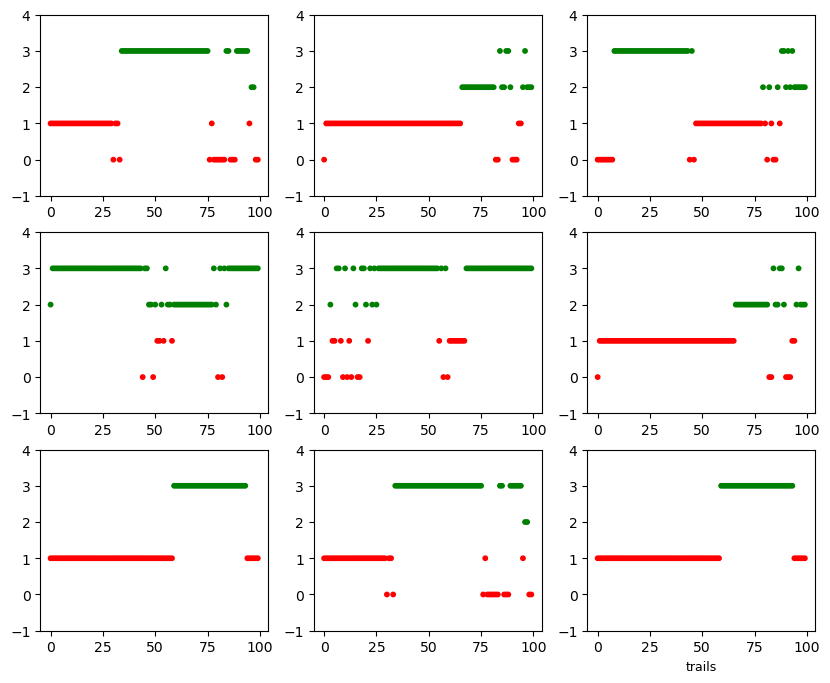

In [27]:
random_pick = np.random.choice(np.arange(EPOCHS), size = 9)

plt.figure(figsize=(10,8))
for i in range(9):
    plt.subplot(3,3,i+1)
    colors = np.where(np.isin(arm_chosen_monitor[random_pick[i]],[0,1]), 'r', 'g')
    plt.scatter(np.arange(TRAILS), arm_chosen_monitor[random_pick[i]], c = colors, s = 10)
    plt.ylim(-1,4)
plt.xlabel('trails', fontsize = 9)


tensor([[-2.6000],
        [ 2.2000],
        [-2.0000],
        [ 5.2000],
        [ 7.2000]]) tensor([[5.4000],
        [5.7151],
        [4.9080],
        [4.4939],
        [4.1333]])


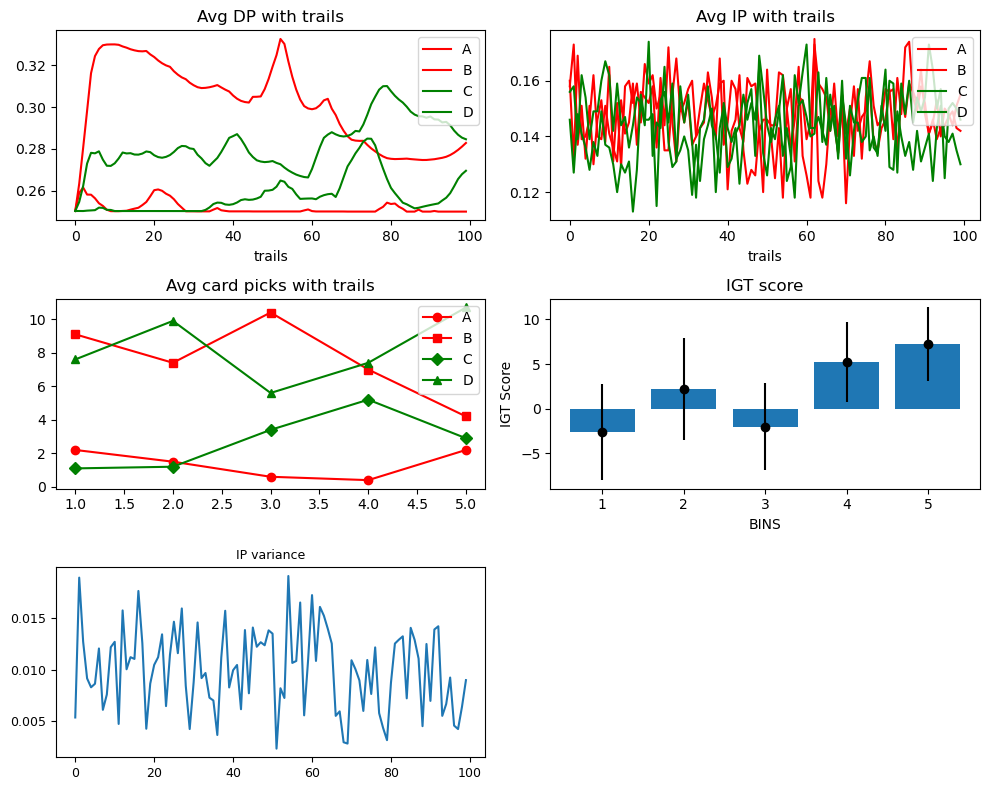

In [28]:
BINS = np.arange(5) + 1

plt.figure(figsize=(10,8))

plt.subplot(321)
plt.plot(np.arange(100), DP_A, label = 'A', color = 'red')
plt.plot(np.arange(100), DP_B, label = 'B', color = 'red')
plt.plot(np.arange(100), DP_C, label = 'C', color = 'green')
plt.plot(np.arange(100), DP_D, label = 'D', color = 'green')
plt.xlabel('trails')
plt.title('Avg DP with trails')
plt.legend(loc = 'upper right')

plt.subplot(322)
plt.plot(np.arange(100), IP_A, label = 'A', color = 'red')
plt.plot(np.arange(100), IP_B, label = 'B', color = 'red')
plt.plot(np.arange(100), IP_C, label = 'C', color = 'green')
plt.plot(np.arange(100), IP_D, label = 'D', color = 'green')
plt.xlabel('trails')
plt.title('Avg IP with trails')
plt.legend(loc = 'upper right')

plt.subplot(323)
plt.plot(BINS,Avg_A_picks, label = 'A', color = 'red', marker = 'o')
plt.plot(BINS,Avg_B_picks, label = 'B', color = 'red', marker = 's')
plt.plot(BINS,Avg_C_picks, label = 'C', color = 'green', marker = 'D')
plt.plot(BINS,Avg_D_picks, label = 'D', color = 'green', marker = '^')
plt.title('Avg card picks with trails')
plt.legend(loc = 'upper right')

plt.subplot(324)
plt.bar(BINS, IGT_score.reshape(5))
print(IGT_score, IGT_dev)
plt.errorbar(BINS, IGT_score.reshape(5), yerr= IGT_dev.reshape(5), fmt='o', color = 'black')
plt.title(f'IGT score')
plt.xlabel('BINS')
plt.ylabel('IGT Score')

plt.subplot(325)
plt.plot(IP_Var)
# plt.ylim(0.0,0.0025)
plt.title('IP variance', fontsize = 9)
plt.xticks(fontsize = 9)
plt.yticks(fontsize = 9)
plt.tight_layout()

plt.tight_layout()

In [29]:
IGT_expt= np.array([-1.83,1.5,2.6,4.59,3.9])
IGT_Simulated = IGT_score.reshape(5)

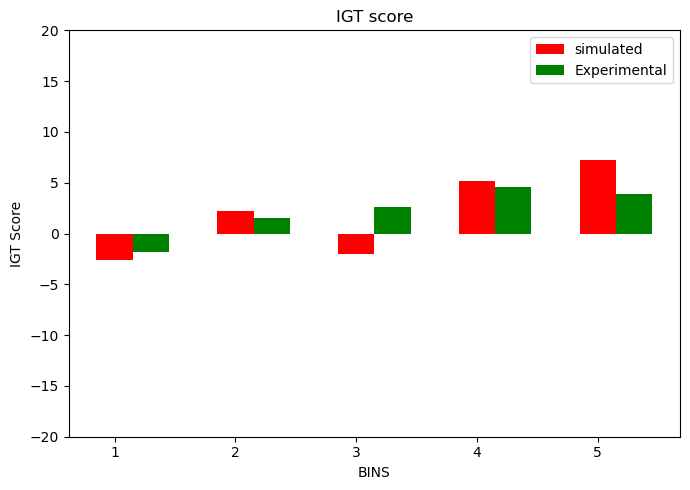

In [30]:
# Plotting bar for IGT
plt.figure(figsize=(7,5))
plt.bar(BINS, IGT_Simulated, width=0.3, color = 'red', label = 'simulated')
plt.bar(BINS+0.3, IGT_expt, width=0.3, color = 'green', label = 'Experimental')
plt.ylim(-20,20)
plt.title(f'IGT score')
plt.xlabel('BINS')
plt.ylabel('IGT Score')
plt.legend()
plt.tight_layout()

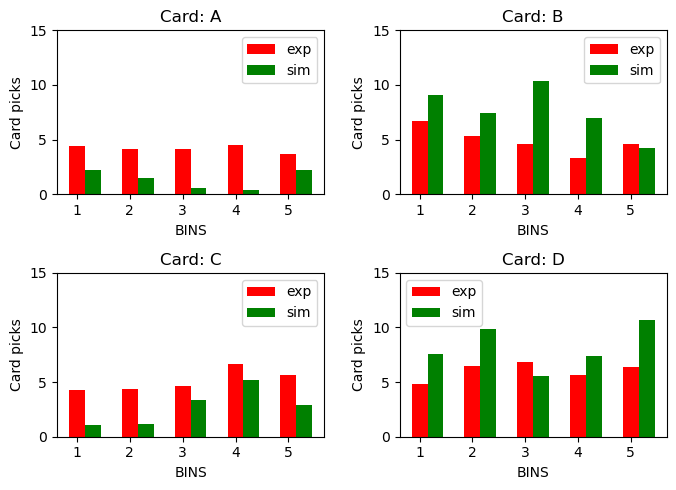

In [31]:
# Comparison each card pick wise
A_experimental = torch.tensor([4.42,4.12,4.1,4.5,3.68])
A_simulated = Avg_A_picks.squeeze()

B_experimental = torch.tensor([6.74,5.35,4.59,3.3,4.57])
B_simulated = Avg_B_picks.squeeze()

C_experimental = torch.tensor([4.28,4.34, 4.63,6.64, 5.63])
C_simulated = Avg_C_picks.squeeze()

D_experimental = torch.tensor([4.83, 6.48, 6.87, 5.68, 6.39])
D_simulated = Avg_D_picks.squeeze()

# Plotting bar chart for card picks
plt.figure(figsize=(7,5))
plt.subplot(221)
plt.bar(BINS, A_experimental, width=0.3, color = 'red', label = 'exp')
plt.bar(BINS+0.3, A_simulated, width=0.3, color = 'green', label = 'sim')
plt.ylim(0,15)
plt.title('Card: A')
plt.xlabel('BINS')
plt.ylabel('Card picks')
plt.legend()

plt.subplot(222)
plt.bar(BINS, B_experimental, width=0.3, color = 'red', label = 'exp')
plt.bar(BINS+0.3, B_simulated, width=0.3, color = 'green', label = 'sim')
plt.ylim(0,15)
plt.title('Card: B')
plt.xlabel('BINS')
plt.ylabel('Card picks')
plt.legend()

plt.subplot(223)
plt.bar(BINS, C_experimental, width=0.3, color = 'red', label = 'exp')
plt.bar(BINS+0.3, C_simulated, width=0.3, color = 'green', label = 'sim')
plt.ylim(0,15)
plt.title('Card: C')
plt.xlabel('BINS')
plt.ylabel('Card picks')
plt.legend()

plt.subplot(224)
plt.bar(BINS, D_experimental, width=0.3, color = 'red', label = 'exp')
plt.bar(BINS+0.3, D_simulated, width=0.3, color = 'green', label = 'sim')
plt.ylim(0,15)
plt.title('Card: D')
plt.xlabel('BINS')
plt.ylabel('Card picks')
plt.legend()

plt.tight_layout()

## Statistical testing

In [32]:
mean_sim = IGT_score.squeeze().detach().numpy()
mean_expt = IGT_expt
std_sim = torch.std(torch.add(C_picks, D_picks) - torch.add(A_picks, B_picks), dim = 0).squeeze().detach().numpy()
std_expt = std_sim
n_sim = 100
n_expt = 20

In [33]:
import math
from scipy.stats import t
import pandas as pd

def compare_multiple_pairs(mean_exp, std_exp, n_exp, mean_sim, std_sim, n_sim):
    results = []

    for i in range(len(mean_exp)):
        m1, s1 = mean_exp[i], std_exp[i]
        m2, s2 = mean_sim[i], std_sim[i]

        # Standard error
        se = math.sqrt((s1**2)/n_exp + (s2**2)/n_sim)

        # t-statistic
        t_stat = (m1 - m2) / se

        # Degrees of freedom (Welch-Satterthwaite)
        df_num = (s1**2/n_exp + s2**2/n_sim)**2
        df_den = ((s1**2/n_exp)**2 / (n_exp - 1)) + ((s2**2/n_sim)**2 / (n_sim - 1))
        df = df_num / df_den

        # Two-tailed p-value
        p_val = 2 * (1 - t.cdf(abs(t_stat), df))
        conclusion = "Statistically different" if p_val < 0.05 else "Not statistically different"

        results.append({
            "Index": i+1,
            "Exp Mean": m1,
            "Sim Mean": m2,
            "t-stat": round(t_stat, 3),
            "p-value": round(p_val, 4),
            "Significant": p_val < 0.05,
            "Conclusion": conclusion

        })

    return pd.DataFrame(results)

# Run comparison
df_results_IGT_mean = compare_multiple_pairs(mean_expt, std_expt, n_expt, mean_sim, std_sim, n_sim)

# Show results
# import ace_tools as tools; tools.display_dataframe_to_user(name="Significance Comparison Results", dataframe=df_results)


In [34]:
df_results_IGT_mean

,Index,Exp Mean,Sim Mean,t-stat,p-value,Significant,Conclusion
0,1,-1.83,-2.6,0.184,0.8553,False,Not statistically different
1,2,1.50,2.2,-0.158,0.8755,False,Not statistically different
2,3,2.60,-2.0,1.210,0.2367,False,Not statistically different
3,4,4.59,5.2,-0.175,0.8622,False,Not statistically different
4,5,3.90,7.2,-1.031,0.3118,False,Not statistically different


In [35]:

# ==================================================
# Compute and save IGT choice/Q metrics for normal run
# ==================================================

CONDITION_NAME = "normal"
DEL_LIM_CURRENT = None

choice_var_metrics = compute_choice_variability_metrics(
    arm_chosen_monitor=arm_chosen_monitor,
    n_arms=NUM_ARMS,
    window_size=15,
    alpha=0.7,
)

q_error_metrics = compute_q_error_metrics(
    dp_monitor=dp_monitor,
    true_values=TRUE_IGT_VALUES,
    n_arms=NUM_ARMS,
)

metrics_data = {
    "CONDITION_NAME": CONDITION_NAME,
    "DEL_LIM_CURRENT": DEL_LIM_CURRENT,
    "DEL_LIM_KEY": "no_limit",
    "DEL_LIM_LABEL": "No limit",
    "SCALING_FACTOR": SCALING_FACTOR,
    "NUM_ARMS": NUM_ARMS,
    "TRIALS": TRAILS,
    "EPOCHS": EPOCHS,
    "NUM_BINS": NUM_BINS,
    "TRUE_IGT_VALUES": TRUE_IGT_VALUES,
    "TRUE_IGT_VALUES_RAW_REFERENCE": TRUE_IGT_VALUES * SCALING_FACTOR,

    # Main required metrics
    "entropy_plus_switching": choice_var_metrics["mean_combined_variability"],
    "q_error": q_error_metrics["mean_q_rmse"],

    # Components
    "entropy": choice_var_metrics["mean_entropy"],
    "switching": choice_var_metrics["mean_switching"],

    # Full metric dictionaries
    "CHOICE_VARIABILITY_METRICS": choice_var_metrics,
    "Q_ERROR_METRICS": q_error_metrics,
}

metrics_file_name = "igt_choice_q_metrics_normal.pkl"
metrics_file_path = os.path.join(
    project_root,
    "simulations",
    "decision_making_tasks",
    "igt",
    metrics_file_name,
)

os.makedirs(os.path.dirname(metrics_file_path), exist_ok=True)
with open(metrics_file_path, "wb") as f:
    pickle.dump(metrics_data, f)

print("Saved normal IGT choice/Q metrics:", metrics_file_path)
print(f"Entropy             = {metrics_data['entropy']:.4f}")
print(f"Switching           = {metrics_data['switching']:.4f}")
print(f"Entropy + switching = {metrics_data['entropy_plus_switching']:.4f}")
print(f"Q-value error       = {metrics_data['q_error']:.4f}")


Saved normal IGT choice/Q metrics: /Users/charithapalika/Desktop/Lab projects/Decision Making/light_house_DBS_decision_making/simulations/decision_making_tasks/igt/igt_choice_q_metrics_normal.pkl
Entropy             = 0.2512
Switching           = 0.1293
Entropy + switching = 0.2146
Q-value error       = 0.3750


## Saving data

In [ ]:
# data_normal = {'IGT_sim': mean_sim,
#                'IGT_sim_std': std_sim,
#                'IGT_exp': mean_expt,
#                'IGT_exp_std': std_expt,
#                'n_expt': n_expt,
#                'n_sim': n_sim,
#                'article': 'Gescheidt',
#                'condition': 'normal',
#                'A_experimental': A_experimental,
#                'B_experimental': B_experimental,
#                'C_experimental': C_experimental,
#                'D_experimental': D_experimental,
#                'A_simulated': A_simulated,
#                'B_simulated': B_simulated,
#                'C_simulated': C_simulated,
#                'D_simulated': D_simulated,
#                'statistical test': df_results_IGT_mean}

In [42]:
# # saving as pickle file

# with open('data_normal_igt.pkl', 'wb') as f:
#     pickle.dump(data_normal, f)